<a href="https://colab.research.google.com/github/emilchafigoulline/Data-Science/blob/main/Unit8/EmilChafU8Proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Life Expectancy ~ County Health & Environment?

For this project, I will be using the counties dataset to investigate what environmental and socioeconomic conditions best predict life expectancy across U.S. counties. The four predictor variables are:

- Violent Crime Rate: number of violent crimes per 100,000 residents
- Annual Snowfall: average yearly snowfall by county
- Housing Cost: median annual housing cost in dollars
- Average PM2.5: average daily particulate matter concentration in air

I will attempt to discover which of theses factors most strongly influences life expectancy, allowing for the discovery important factors when considering where to live and how each county influences this.

In [ ]:
!pip install pymc-bart
!pip install preliz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.9/179.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.9/513.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 18.5 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0


In [ ]:
import arviz as az
import graphviz as gv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc_bart as pmb
import seaborn as sns

# Data

I will be predicting life expectancy by using four environmental and socioeconomic predictors: violent crime rate, annual snowfall, housing costs, and average daily PM2.5. I'm assuming that each of these factors has at least a marginal effect on how long residents of a county live on average. The violent crime rate and PM2.5 are expected to harm life expectancy, while higher housing costs would represent wealthier communities with better access to healthcare. Finally, snowfall is a variable that might have an effect on living in the cold and correlating it with life expectancy.

In [ ]:
countiesdata = pd.read_csv('https://raw.githubusercontent.com/emilchafigoulline/data-science-fundamentals/refs/heads/main/Data/counties.csv')
selecteddata = countiesdata[['name', 'noaa/snow', 'life-expectancy', 'health/Violent Crime Rate', 'cost-of-living/housing_costs', 'health/Average Daily PM2.5']].dropna()
selecteddata.head()

,name,noaa/snow,life-expectancy,health/Violent Crime Rate,cost-of-living/housing_costs,health/Average Daily PM2.5
0,cuming county,28.2,81.20,22.125118,5460.0,7.1
1,lancaster county,25.3,80.46,325.955385,7452.0,6.7
3,keith county,25.0,79.24,105.741121,6312.0,4.9
4,phelps county,26.7,79.86,97.097853,5460.0,5.7
5,webster county,21.5,78.78,110.420980,6312.0,5.9


Here is my DAG. Housing costs and violent crime rate both influence each other, with more violent crime driving costs down, along with higher costs driving violent crime down due to the broken windows theory. Snowfall can also affect the amount of particulate matter in the air, and both of these factors affecting housing costs. Then, all of these factors have some effect on life expectancy, increasing or decreasing it in some way.

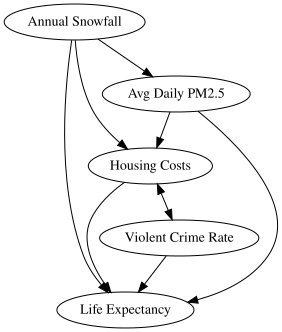

In [24]:
dag_counties = gv.Digraph(name='counties_dag')

dag_counties.node('L', 'Life Expectancy')
dag_counties.node('V', 'Violent Crime Rate')
dag_counties.node('S', 'Annual Snowfall')
dag_counties.node('H', 'Housing Costs')
dag_counties.node('P', 'Avg Daily PM2.5')

dag_counties.edges(['VL', 'SL', 'HL', 'PL'])
dag_counties.edge('P', 'H')
dag_counties.edge('S', 'P')
dag_counties.edge('S', 'H')
dag_counties.edge('H', 'V', dir='both')

dag_counties

# Pairplot

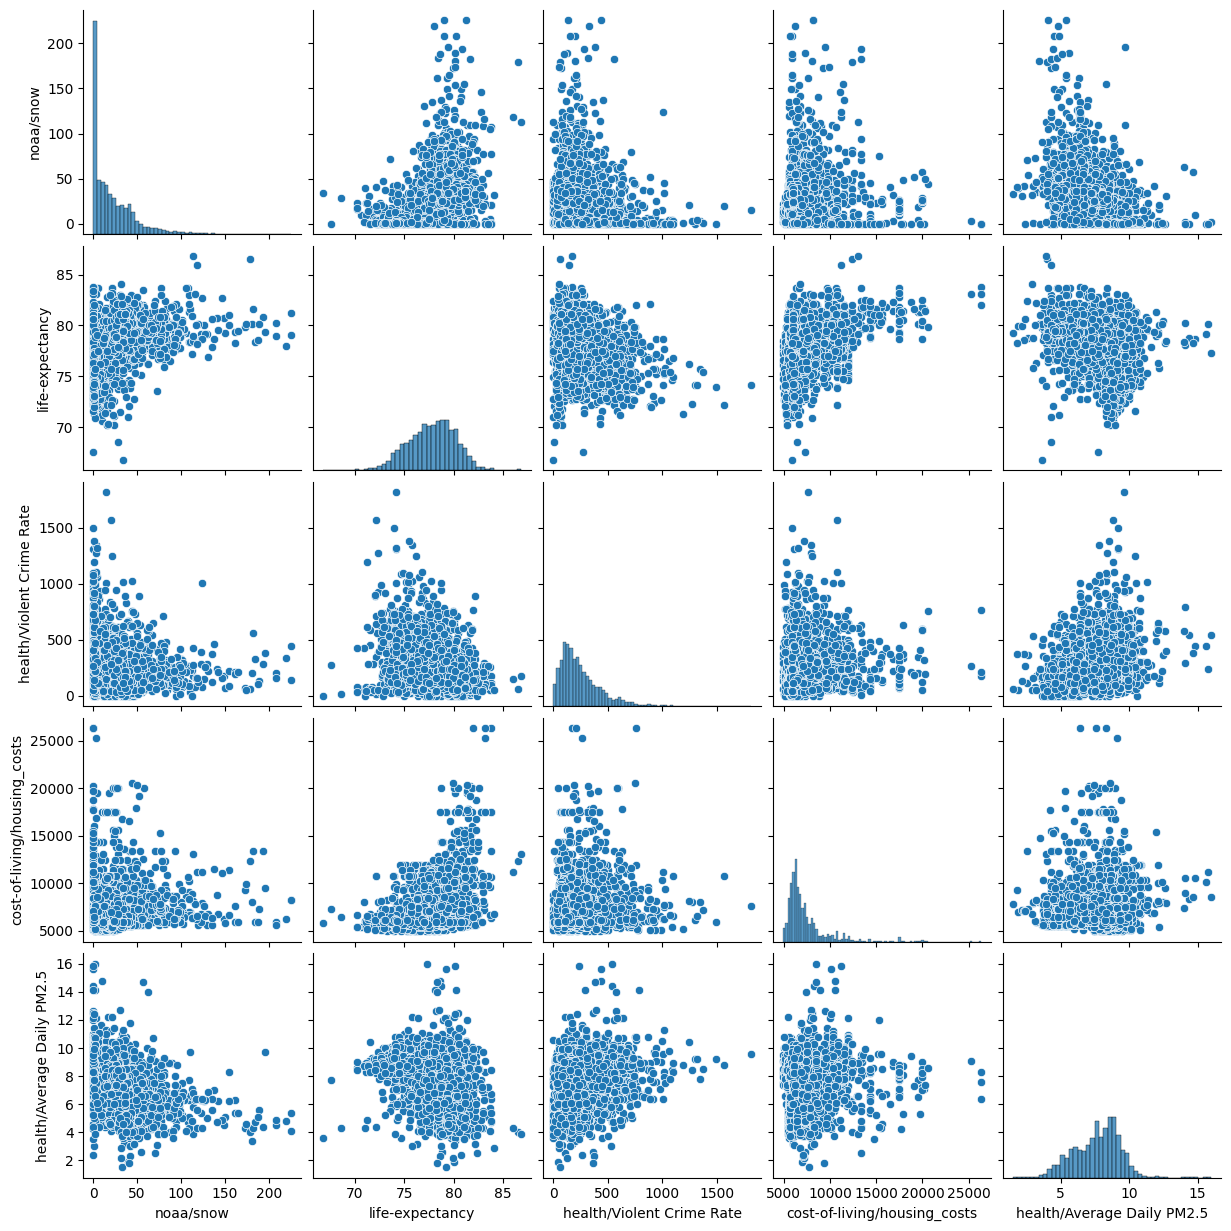

In [ ]:
sns.pairplot(selecteddata.drop(columns=['name']))

The pairplot an overview of the relationships between all variables. Housing costs and life expectancy appear positively correlated, while violent crime rate shows a negative association with life expectancy. PM2.5 also appears negatively correlated with longevity, which makes sense with more particulate matter being worse for the lungs. Snowfall is spread across a wide range and its relationship to life expectancy doesn't look like it has a great effect, but it may have some effect on the other variables I am using.

# Model Preparation

Life expectancy must be positive, so I normalized it to have mean 0 and standard deviation 1. This lets me use a Normal likelihood without the log/exp transformation. This also allows the BART to only range over the real numbers, which is the range neccessary for lifespan.

In [25]:
X = selecteddata[['health/Violent Crime Rate', 'noaa/snow', 'cost-of-living/housing_costs', 'health/Average Daily PM2.5']]
Y_raw = selecteddata['life-expectancy'].to_numpy()
Y = (Y_raw - Y_raw.mean()) / Y_raw.std()


# BART Model

Here is my BART model, in which I use all of my predictors. Because I normalized life expectancy, I used a normal distribution. The HalfNormal prior on sigma is an uninformative guess that stems from lack of prior knowledge.

In [ ]:
with pm.Model() as model_life:
    s = pm.HalfNormal('s', 1)
    μ_ = pmb.BART('μ_', X, Y, m=50)
    μ = pm.Deterministic('μ', μ_)
    y = pm.Normal('y', mu=μ, sigma=s, observed=Y)
    idata_life = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_life, model_life, extend_inferencedata=True)

## Posterior Predictive Check



Text(0.5, 1.0, 'Posterior Predictive Check — Life Expectancy (normalized)')

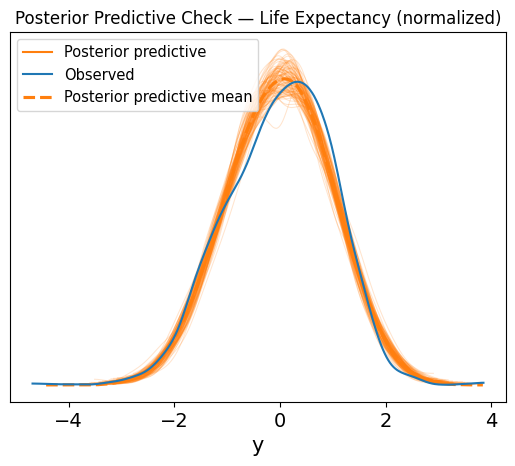

In [ ]:
ax = az.plot_ppc(idata_life, num_pp_samples=100, colors=['C1', 'C0', 'C1'])
ax.set_title('Posterior Predictive Check — Life Expectancy (normalized)')

This fit tells us that our model is fairly accurate at predicting life expectancy, with peaks matching and a fairly close line. The predicted and observed are close in range, peaks, and spreads, indicating that the variables I selected are fairly representative for predicting lifespan.

## Posterior Predictive vs. Violent Crime Rate

Now, I'll plot the posterior predictive and HDI against violent crime rate, since I expect this to be the variable with the most direct relationship to life expectancy.

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


[Text(0.5, 1.0, 'Posterior Predictive — Life Expectancy vs. Violent Crime Rate'),
 Text(0.5, 0, 'Violent Crime Rate'),
 Text(0, 0.5, 'Life Expectancy (normalized)')]

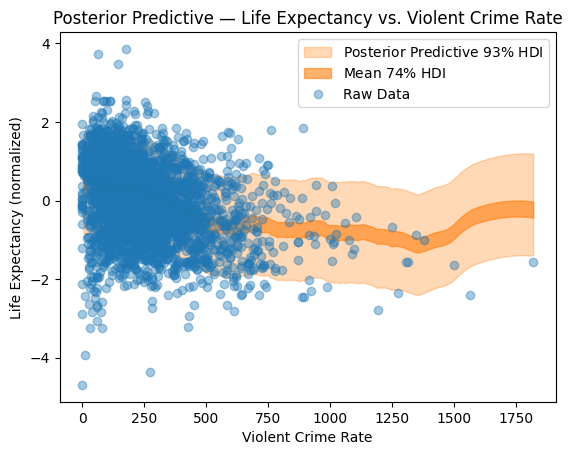

In [ ]:
posterior_mean = idata_life.posterior['μ']

pps = az.extract(
    idata_life, group='posterior_predictive', var_names=['y']
).T

Xarr = X.to_numpy()

fig, ax = plt.subplots()

az.plot_hdi(
    x=Xarr[:, 0],
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={'alpha': 0.3, 'label': r'Posterior Predictive $93\%$ HDI'},
)

az.plot_hdi(
    x=Xarr[:, 0],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={'alpha': 0.6, 'label': r'Mean $74\%$ HDI'},
)

ax.plot(Xarr[:, 0], Y, 'o', c='C0', label='Raw Data', alpha=0.4)
ax.legend(loc='upper right')
ax.set(
    title='Posterior Predictive — Life Expectancy vs. Violent Crime Rate',
    xlabel='Violent Crime Rate',
    ylabel='Life Expectancy (normalized)',
)

As I expected, there is a generally negative relationship between violent crime rate and life expectancy. The data fits fairly well within our graph as it indicates that greater violent crime rate leads to lower life expectancy. However, one problem that I've encountered is that violent crime rate data thins out significantly, leading to a lower number of data points with high violent crime, lowering the significance of the data, along with my model's reliability.

## Variable Importance, Partial Dependence, and ICE Plots

<Axes: ylabel='R²'>

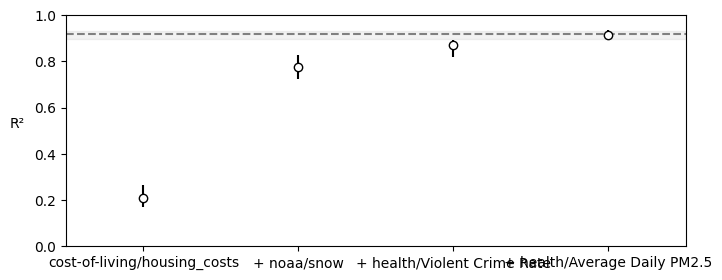

In [ ]:
vi_life = pmb.compute_variable_importance(idata_life, μ_, X)
pmb.plot_variable_importance(vi_life)

array([<Axes: xlabel='health/Violent Crime Rate'>,
       <Axes: xlabel='noaa/snow'>,
       <Axes: xlabel='cost-of-living/housing_costs'>,
       <Axes: xlabel='health/Average Daily PM2.5'>], dtype=object)

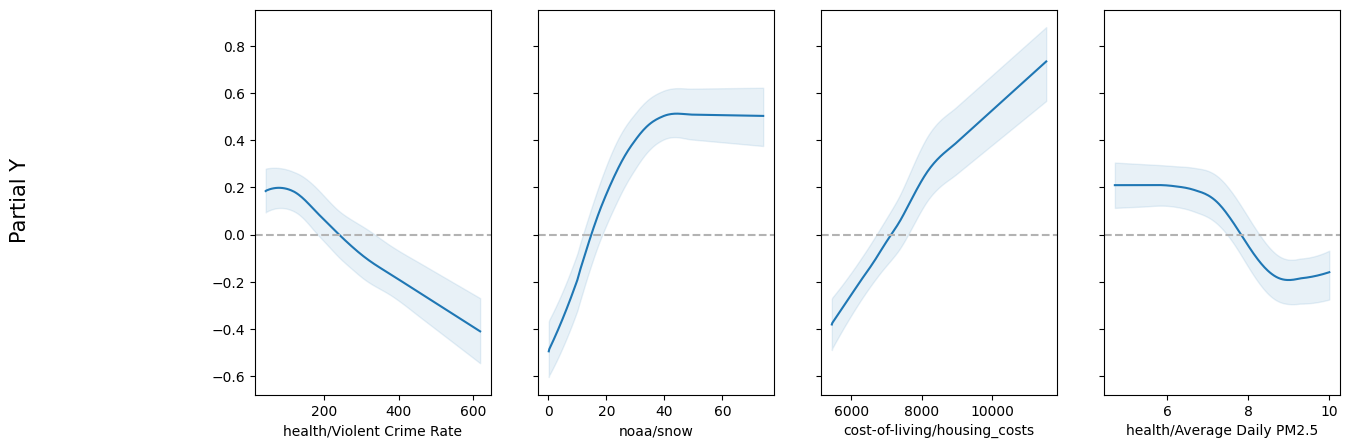

In [ ]:
pmb.plot_pdp(μ_, X, Y, grid=(1, 4), figsize=(14, 5))

array([<Axes: xlabel='health/Violent Crime Rate'>,
       <Axes: xlabel='noaa/snow'>,
       <Axes: xlabel='cost-of-living/housing_costs'>,
       <Axes: xlabel='health/Average Daily PM2.5'>], dtype=object)

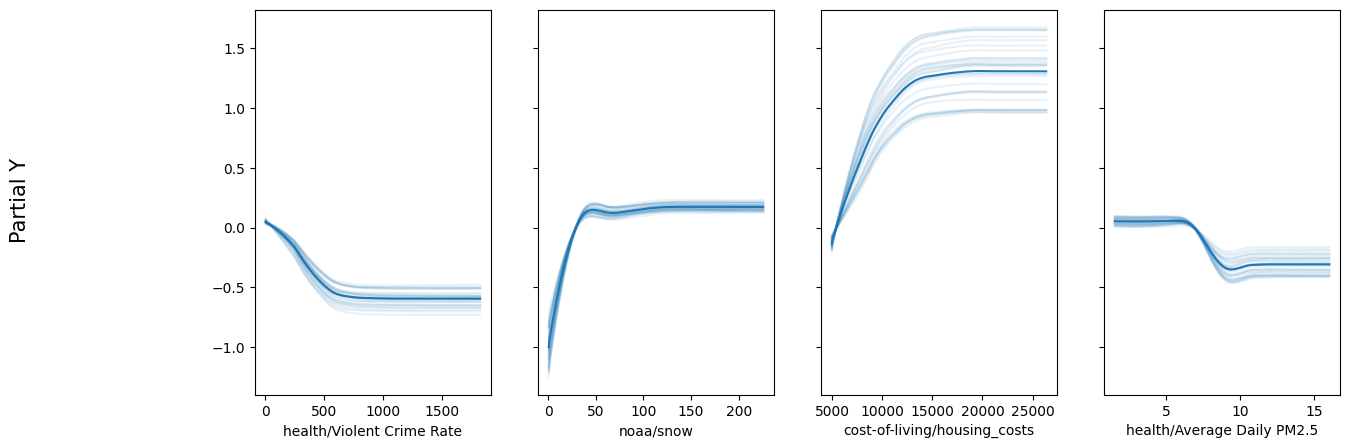

In [ ]:
pmb.plot_ice(μ_, X, Y, grid=(1, 4), figsize=(14, 5))

This VI plot actually returned a result that was completely different from what I expected. Instead of a factor such as PM2.5 or Violent Crime Rate having the greatest correlation with life expectancy, it actually appears to be snow which accounts the most for life expectancy. While I didn't expect this, it is still interpretable. Snow must either be a proxy for some other variable, such as location, or it is actually the most important factor. However, by looking at our ICE plot, we can see that the effect that snow has on life expectancy is actually fairly constant. This indicates that snow isn't simply an outlier, but instead an actual predictor for life expectancy. After snow, the variables in order of importance were housing costs, then violent crime rates, then PM2.5 levels.

# Part II: Reduced BART Model — Dropping the Weakest Predictor

Based on the variable importance plot above, I will drop the predictor with the lowest importance score (PM2.5) and refit the model to see whether this simplification helps or hurts. If PM2.5 actually has no effect on life expecatancy, dropping it should either have no effect on my model's accuracy or actually improve it.

In [ ]:
X_reduced = X.drop(columns=['health/Average Daily PM2.5'])

with pm.Model() as model_life_reduced:
    s = pm.HalfNormal('s', 1)
    μ_r = pmb.BART('μ_', X_reduced, Y, m=50)
    μ = pm.Deterministic('μ', μ_r)
    y = pm.Normal('y', mu=μ, sigma=s, observed=Y)
    idata_life_reduced = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_life_reduced, model_life_reduced, extend_inferencedata=True)

Text(0.5, 1.0, 'Posterior Predictive Check — Reduced Model (no PM2.5)')

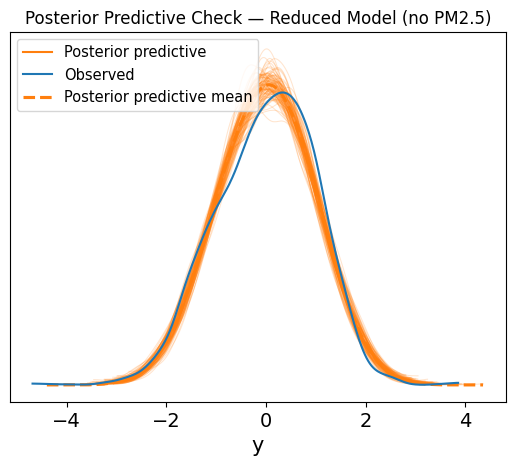

In [33]:
ax = az.plot_ppc(idata_life_reduced, num_pp_samples=100, colors=['C1', 'C0', 'C1'])
ax.set_title('Posterior Predictive Check — Reduced Model (no PM2.5)')

<Axes: ylabel='R²'>

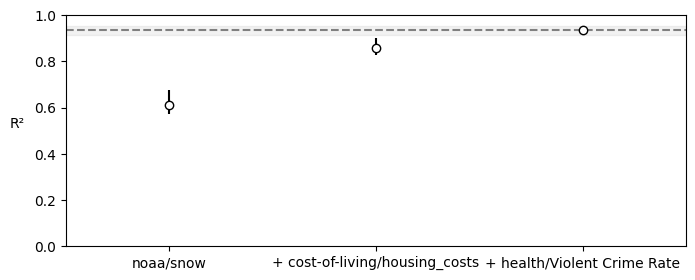

In [30]:
vi_reduced = pmb.compute_variable_importance(idata_life_reduced, μ_r, X_reduced)
pmb.plot_variable_importance(vi_reduced)

array([<Axes: xlabel='health/Violent Crime Rate'>,
       <Axes: xlabel='noaa/snow'>,
       <Axes: xlabel='cost-of-living/housing_costs'>], dtype=object)

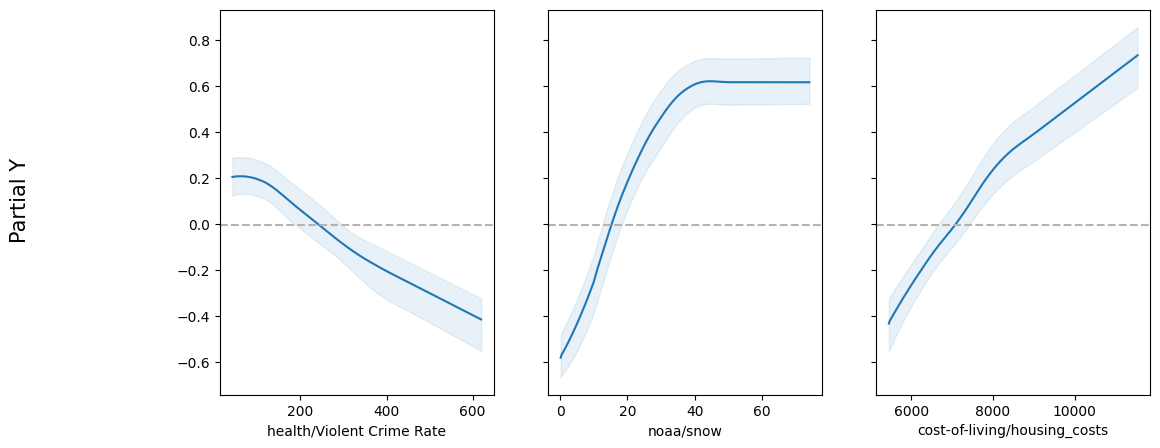

In [31]:
pmb.plot_pdp(μ_r, X_reduced, Y, grid=(1, 3), figsize=(12, 5))

array([<Axes: xlabel='health/Violent Crime Rate'>,
       <Axes: xlabel='noaa/snow'>,
       <Axes: xlabel='cost-of-living/housing_costs'>], dtype=object)

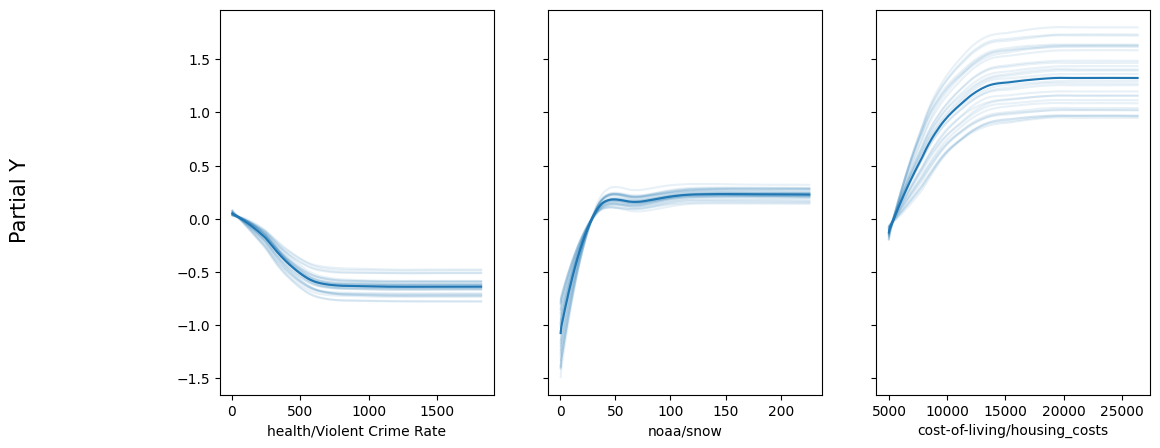

In [32]:
pmb.plot_ice(μ_r, X_reduced, Y, grid=(1, 3), figsize=(12, 5))

## Comparing the Two Models

After looking at the comparisons between the two models, we can see that the R^2 value of the two VI plots didn't change much, and so we can conclude that PM2.5 wasn't a very strong predictor for life expectancy. In addition, our ICE plots became less spread out, also indicating that PM2.5 wasn't contributing much to our model's prediction.

# Conclusion

This project used a BART model to predict life expectancy by using four predictors: violent crime rate, annual snowfall, housing costs, and average daily PM2.5. While I initially predicted that housing costs and violent crime rate would likely be the strongest predictors of life expectancy, which made intuitive sense: wealthier, safer counties tend to have better healthcare access, lower crime rates, and more safeguards.

However, snowfall unexpectedly had the greatest R^2 value on the VI plot, and it also a low variance in the ICE plot, indicating that its effects weren't actually spurious. Instead, snowfall appears to be a meaningful predictor of life expectancy.

Also unexpeced was the weakness of prediction that the model gained from particulate matter levels, as seen above, the VI plot didn't change much when PM2.5 was removed.

As such, this project can conclude that while all of these predictors are quite helpful for establishing life expectancy predictions, snowfall is actually the most important, or some other underlying factor that snowfall acts as a proxy for.